**Coursebook: Unsupervised Learning**
    
- Part of Comprehensive Data Science and Machine Learning Program for PT Freeport Indonesia
- Course Length: 6 Hours
- Last Updated: September 2025

---

Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

# Background

The coursebook is part of the **Comprehensive Data Science and Machine Learning Program** prepared by [Algoritma](https://algorit.ma/). The coursebook is intended for a restricted audience only, i.e. the individuals and organizations having received this coursebook directly from the training organization. It may not be reproduced, distributed, translated or adapted in any form outside these individuals and organizations without permission.

Algoritma is a data science education center based in Jakarta. We organize workshops and training programs to help working professionals and students gain mastery in various data science sub-fields: data visualization, machine learning, data modeling, statistical inference etc.

## Training Objectives

This coursebook is intended for participants who have completed the preceding courses. 

The coursebook focuses on:

* **Introduction to Unsupervised Learning**
    * Supervised vs Unsupervised Learning
* **K-Means Clustering**
    * Understanding and Practicing K-Means
    * Optimal Number of Cluster
* **K-Medoids Clustering**
    * Understanding and Practicing K-Medoids
    * Choosing Right Clustering Method based on Data

In [1]:
import warnings

# for data manipulation
import pandas as pd 
# for matrix-based computation
import numpy as np

# data visualization
import matplotlib.pyplot as plt

# clustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# Gower matrix
import gower as go

# custom functions
from helper import plot_elbow_kmeans, plot_elbow_kmedoids, biplot_kmeans, plot_depth_readings_cluster

In [2]:
# pandas display and formatting option
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
warnings.simplefilter(action='ignore', category=FutureWarning)

# Introduction to Unsupervised Learning

**Supervised Learning vs Unsupervised Learning**

Machine learning is a subset of artificial intelligence that enables computer systems to learn so that they can automate processes. The main concept behind  machine learning is to allow a model or algorithm to analyze large amounts of data, learn from that data, and then make predictions or decisions based on the new data.

Machine learning is divided into two types, namely **supervised learning** and **unsupervised learning**. The main difference between supervised learning and unsupervised learning is in the level of feedback provided. In supervised learning, the model is trained on data that is already labeled. So that the expected output is clear enough according to the label in the data. While the unsupervised learning method, the algorithm performs the modeling process on unlabeled data, so that to determine the output, the model must learn based on the data pattern.

**Supervised Learning Ilustration**

![Supervised Learning](assets/SL.jpg)

In the illustration above at STEP 1, the machine learns from the labeled data. Then, the model stores the learning results to be used in the new data prediction process. So that when entering the STEP 2 section, the output of the new data prediction results will adjust to the label from the learning results.

Some examples of the application of supervised learning algorithms are **regression** and **classification**.

**Unsupervised Learning Ilustration**

![Unsupervised Learning](assets/UL.jpg)

In the illustration above at STEP 1, the machine will understand the pattern of randomly arranged data. The machine will learn to distinguish the characteristics of each data and then the model will store the information. So that when entering STEP 2, the model will make observations on new data based on the information that has been stored from the learning results.

Some examples of the application of unsupervised learning algorithms are **dimensionality reduction** and **clustering**.

# Study Case: Clustering on Well Logging Data

## Problem Statement

Wells are a crucial component in the oil and gas industry. In this context, oil and gas are extracted from the earth's subsurface through previously drilled wells. During the well construction process, it is often necessary to determine whether the well being drilled contains the sought-after energy mineral resources. This process involves inserting logging tools into the well to reach a certain depth.

![](assets/well_logging.jpg)

The structure of the logging tools resembles a pipe composed of several components. Each component of the logging tools serves a different purpose in analyzing the material structure surrounding the well. For instance, gamma ray tools in the logging equipment are used to study rock radiation. Resistivity tools are used to examine the electric conductivity properties of formation supports. In addition to the parts mentioned previously, there are components of the logging tools that analyze carbon content, rock density levels, and other parts used in different excavation structures.

Each component of the logging tools generates data that geologists can use to assess whether the well excavation has sufficient potential for the well completion process. This process includes the analysis of rock formation structures that surround the drilled well. The image below is an example of well logging data.
![](assets/well_logging_data.png)
If the well has sufficient mining potential, the well completion process will be carried out.

In this section, we will use well logging data from the [FORCE 2020 Well well log and lithofacies dataset for machine learning competition](https://zenodo.org/records/4351156). This well log dataset from 118 wells in the Norwegian sea has been utilized in the FORCE 2020 machine learning competition to predict lithofacies using seismic data and wells with machine learning models.

> The original data source can be viewed at [this link](https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition/tree/master/lithology_competition/data) with the file named `train.zip`.

For the purpose of this lesson, we will use well logging data from well ID 25/2-7. If we access the original link mentioned above, we will find many missing values in several columns. For this learning exercise, we have preprocessed, sampled, and replaced the null values with either zeros or any statistical measurements.

## Load Data

Let's read our preprocessed data (`train_well_25_2_7_sampled.csv`) within `data_input` folder!

In [3]:
# load data
well_2527 = pd.read_csv('data_input/train_well_25_2_7_sampled.csv')

# 5 first observations
well_2527.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LITHOLOGY_CLASS_CONFIDENCE
0,25/2-7,204.594,479890.531,6641111.500,-179.591,NORDLAND GP.,Vaale Fm.,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,2
1,25/2-7,206.722,479890.531,6641111.500,-181.719,NORDLAND GP.,Vaale Fm.,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,2
2,25/2-7,208.850,479890.531,6641111.500,-183.847,NORDLAND GP.,Vaale Fm.,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,1
3,25/2-7,212.802,479890.531,6641111.500,-187.799,NORDLAND GP.,Vaale Fm.,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Sandstone/Shale,1
4,25/2-7,212.954,479890.531,6641111.500,-187.951,NORDLAND GP.,Vaale Fm.,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,Sandstone/Shale,1


In [4]:
# 5 last observations
well_2527.tail()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LITHOLOGY_CLASS_CONFIDENCE
2495,25/2-7,4015.690,479837.719,6641081.000,-3989.777,DUNLIN GP.,Sleipner Fm.,9.899,4.568,4.568,3.667,2.586,94.123,0.000,0.264,4.813,84.304,92.971,8.500,0.000,0.000,0.000,0.349,0.000,0.000,0.000,0.000,Shale,1
2496,25/2-7,4016.906,479837.688,6641081.000,-3990.992,DUNLIN GP.,Sleipner Fm.,9.457,4.218,4.218,3.316,2.354,102.151,0.000,0.282,4.941,88.406,93.600,8.500,0.000,0.000,0.000,0.247,0.000,0.000,0.000,0.000,Shale,1
2497,25/2-7,4017.058,479837.688,6641081.000,-3991.144,DUNLIN GP.,Sleipner Fm.,9.459,4.174,4.174,3.307,2.429,100.566,0.000,0.278,5.023,88.783,93.718,8.500,0.000,0.000,0.000,0.275,0.000,0.000,0.000,0.000,Shale,1
2498,25/2-7,4018.730,479837.625,6641080.500,-3992.815,DUNLIN GP.,Sleipner Fm.,9.441,4.512,4.512,3.558,2.482,101.590,0.000,0.302,4.708,86.998,93.809,8.500,0.000,0.000,0.000,0.308,0.000,0.000,0.000,0.000,Shale,1
2499,25/2-7,4019.490,479837.625,6641080.500,-3993.574,DUNLIN GP.,Sleipner Fm.,10.389,4.726,4.726,3.559,2.351,96.603,0.000,0.294,5.089,85.567,94.045,8.500,0.000,0.000,0.000,0.285,0.000,0.000,0.000,0.000,Sandstone/Shale,1


In [5]:
well_2527['LITHOLOGY_CLASS'].unique()

array(['Sandstone/Shale', 'Sandstone', 'Shale', 'Coal', 'Limestone',
       'Dolomite', 'Tuff', 'Marl'], dtype=object)

In [6]:
well_2527['LITHOLOGY_CLASS_CONFIDENCE'].unique()

array([2, 1, 3], dtype=int64)

In [7]:
well_2527['ROP'].min(), well_2527['ROP'].max()

(0.0, 27.709844589)

The data contains the metadata columns:

- `WELL`: well name.
- `DEPTH_MD`: measured depth (m).
- `X_LOC`: UTS x coordinate.
- `Y_LOC`: UTM y coordinate.
- `Z_LOC`: depth (m).
- `GROUP`: NPD lithostratigraphy group.
- `FORMATION`: NPD lithostratigraphy formation.

The data contains the well log curves:

- `BS`: borehole size (inch). 
- `CALI`: caliper log (inch).
- `RHOB`: bulk density log (g/cm3).
- `GR`: gamma ray log (API, American Petroleum Institute, unit).
- `SGR`: spectra gamma ray log (API unit).
- `ROP`: rate of penetration (m/h).
- `NPHI`: neutron porosity log (fraction, can be interpreted in percentage term).
- `PEF`: photoelectric absorption factor log (barns/electron).
- `RSHA`: shallow reading resistivity measurement (Ω.m).
- `RMED`: medium deep reading resistivity measurement (Ω.m).
- `RDEP`: deep reading resistivity measurement (Ω.m).
- `DTS`: shear wave sonic log (µs/ft).
- `DTC`: compressional wave sonic log (µs/ft).

As well as the interpretation:

- `LITHOFACIES_CLASS`: lithology class label (interpreted by expert geologists).
- `LITHOFACIES_CLASS_CONFIDENCE`: confidence in lithology interpretation (1: high, 2: medium, 3: low).

> **Note**: Although our data is labeled with the presence of `LITHOFACIES_CLASS`, our objective in this course is to **use unsupervised learning to map this lithofacies given its well logging data**. We could compare the `LITHOFACIES_CLASS` column and the label learned from our unsupervised model.

## Data Preparation

In the data preparation process, there are several steps that will be carried out to ensure our data is ready for modeling. Some of these steps include looking at the information in the data, checking for missing values, and identifying duplicates.

In [8]:
# the information in the data
well_2527.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   WELL                        2500 non-null   object 
 1   DEPTH_MD                    2500 non-null   float64
 2   X_LOC                       2500 non-null   float64
 3   Y_LOC                       2500 non-null   float64
 4   Z_LOC                       2500 non-null   float64
 5   GROUP                       2500 non-null   object 
 6   FORMATION                   2500 non-null   object 
 7   CALI                        2500 non-null   float64
 8   RSHA                        2500 non-null   float64
 9   RMED                        2500 non-null   float64
 10  RDEP                        2500 non-null   float64
 11  RHOB                        2500 non-null   float64
 12  GR                          2500 non-null   float64
 13  SGR                         2500 

In [10]:
# check for missing values
well_2527.isna().sum()

WELL                          0
DEPTH_MD                      0
X_LOC                         0
Y_LOC                         0
Z_LOC                         0
GROUP                         0
FORMATION                     0
CALI                          0
RSHA                          0
RMED                          0
RDEP                          0
RHOB                          0
GR                            0
SGR                           0
NPHI                          0
PEF                           0
DTC                           0
SP                            0
BS                            0
ROP                           0
DTS                           0
DCAL                          0
DRHO                          0
MUDWEIGHT                     0
RMIC                          0
ROPA                          0
RXO                           0
LITHOLOGY_CLASS               0
LITHOLOGY_CLASS_CONFIDENCE    0
dtype: int64

In [11]:
# check for duplicates
well_2527[well_2527.duplicated()]

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LITHOLOGY_CLASS_CONFIDENCE


> The data contain no missing or duplicated values.

## Data Preprocessing: Feature Scaling

Feature scaling is the process of normalizing or standardizing the values of features (variables) in a dataset so that the values have a uniform scale. Specifically, we refer to feature scaling as **z-score standardization**. This process changes the feature values so that they have a mean of zero and a standard deviation of one. Each feature value is subtracted from the feature mean, and the result is divided by the feature standard deviation.

$$x_{new}=\frac{(x-\bar x)}{std(x)}$$

The main purpose of scaling is to make the data in each column similar to each other and to ensure that machine learning models can work properly and produce more accurate results. This needs to be done because **variance and covariance values are affected by the scale of the data**. The higher the scale, the higher the variance or covariance value.

Before performing the data standardization process, we will first conduct a data filtering process for numeric columns only.

In [11]:
# filter only the appropriate numerical variables
well_num = well_2527[['DEPTH_MD', 'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF', 'DTC', 'SP', 'BS']]

Pay attention to the descriptive summary below! Before preprocessing, each column has a different scale and standard deviation.

In [12]:
# pre-scaling statistical summary
well_num.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,2148.903,15.641,5.554,5.396,4.481,2.215,54.589,0.132,3.621,116.027,50.112,14.228
std,1094.089,4.152,27.701,31.654,21.947,0.260,35.368,0.159,1.555,31.527,15.683,3.621
min,204.594,8.141,0.374,0.374,0.333,1.412,9.025,0.000,0.831,55.657,12.937,8.500
25%,1235.800,12.500,0.808,0.808,0.902,2.031,31.890,0.000,2.525,86.294,38.802,12.250
50%,2146.850,17.949,1.351,1.351,1.436,2.135,47.967,0.000,3.290,120.642,46.191,17.500
75%,3101.638,18.531,3.654,3.617,3.309,2.441,64.602,0.276,4.513,145.319,60.981,17.500
max,4019.490,24.031,834.524,1196.175,758.366,2.959,710.987,0.636,12.085,166.920,94.045,17.500



To perform standardization, we can use the `StandardScaler()` object from the `sklearn.preprocessing` module. We first need to declare this object and assign it to a variable. Once declared, we will pass the numerical columns to the `fit_transform()` function. This function calculates the mean and standard deviation for each column and uses these values to transform the old values into new values based on the formula we have seen before.

In [13]:
# define StandardScaler() object
scaler = StandardScaler()

In [14]:
well_num_scaled = well_num.copy()

# list numeric columns
cols = well_num.columns

In [15]:
# fit and scaling
well_num_scaled[cols] = scaler.fit_transform(well_num_scaled[cols]) 

In [16]:
# post-scaling statistical summary
well_num_scaled.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.777,-1.806,-0.187,-0.159,-0.189,-3.093,-1.289,-0.835,-1.795,-1.915,-2.371,-1.582
25%,-0.835,-0.756,-0.171,-0.145,-0.163,-0.709,-0.642,-0.835,-0.706,-0.943,-0.721,-0.546
50%,-0.002,0.556,-0.152,-0.128,-0.139,-0.307,-0.187,-0.835,-0.213,0.146,-0.250,0.904
75%,0.871,0.696,-0.069,-0.056,-0.053,0.868,0.283,0.903,0.574,0.929,0.693,0.904
max,1.710,2.021,29.932,37.626,34.358,2.864,18.563,3.175,5.445,1.615,2.802,0.904


> After being transformed, the mean and standard deviation become uniform, at 0 and 1, respectively.

# Clustering

**Clustering** refers to the practice of finding meaningful ways to group data, or create subgroups, within a dataset; the resulting groups are usually called clusters. The objective is to create partitions where the observations within each partition are similar to others in that group, while ensuring that the partitions are distinct from one another.

In this part, we will discuss two common clustering methods: K-means and K-medoids.

## K-Means Clustering

**K-means** is a centroid-based clustering algorithm that follows a simple procedure of classifying a given dataset into a predetermined number of clusters, denoted as "$k$". This procedure essentially consists of a series of iterations where we:

1. **Random initialization**: Find cluster centers randomly.
2. **Cluster assignment**: Assign each observation to the nearest cluster based on the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) calculation.
3. **Centroid update**: Shift the centroid to the average (mean) of the observations in each cluster.
4. Repeat steps 2 and 3 until no observation changes its cluster assignment.

![](assets/kmeans.jpg)

A few technicalities: instead of saying "cluster centers," we'll call them "centroids." Also, in the first iteration of the above procedure, because there are no predefined clusters in our feature space, we cannot compute any centroids. Thus, in the first "iteration," we randomly assign our centroids. It turns out that, with enough iterations, the procedure usually converges to a reasonably good solution, providing very reasonable $k$ centroids.

### Optimal Number of Cluster

In the previous section, we learned that K-means works by grouping data into $k$ predefined clusters. However, this raises the question: what is the best value of $k$ for clustering the data? To answer this question, we can try two approaches:

**1. The business Approach**

In this approach, Where we have already defined how many clusters the data will be grouped into. If we apply this approach to the case being discussed, we can set the value of $k$ to the number of unique values in the `LITHOLOGY_CLASS` column. This column can act as a ground truth where we can verify whether our clustering results are good enough to group types of rock (lithofacies). However, it is important to remember that in the real world, **unsupervised learning processes do not involve ground truth.**

In [9]:
well_2527['LITHOLOGY_CLASS'].nunique()

8

> **Note**: According to the original data documentation, this column (before subsetted) has 12 unique classes.

**2. The Statistical/Mathematical Approach**

A frequently used method to determine the value of $k$ is **The Elbow Method**.

The metric that measures the closeness of distances between observations in a cluster is called the **within-cluster sum of squares (WSS)**. The smaller the WSS value, the more similar the observations within the cluster are to each other. This indicates that the cluster formed is sufficiently cohesive.

The working principle of the elbow plot is that K-means will be run multiple times, displaying various WSS values for each number of clusters created, with the results presented visually. The point where the decrease in WSS value slows down (similar to the elbow on an arm) indicates a good $k$ value.

Here is an example of implementing an elbow plot to help us determine the number of $k$ in the `well_num_scaled` data clustering process by importing the prepared function from the helper script.

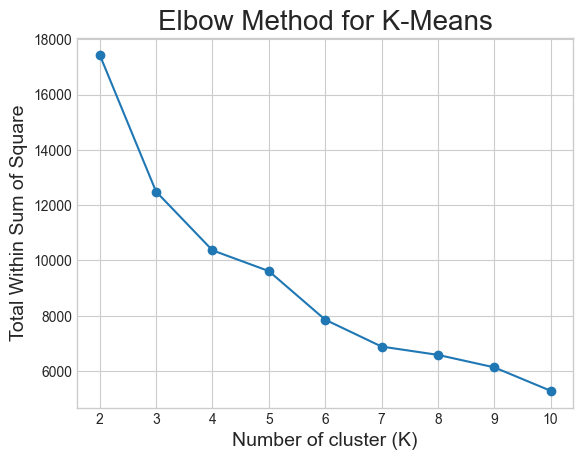

In [19]:
plot_elbow_kmeans(well_num_scaled)

From the image above, the elbow or the $k$ value where the decrease in WSS is not too drastic is around $k = 8$ or $k = 9$.

### K-Means Implementation

In implementing the K-means algorithm, we conduct preprocessing. We begin with data preparation, where we need to check whether missing or duplicated values are present. Next, we perform preprocessing steps in which we include only the numerical variables and scale the numbers to have the same standard deviation. This data preprocessing is important since K-means is based on Euclidean distance, which emphasizes data proximity and closeness.

Previously, we have conducted two different approaches to determine the right number of $k$ and ended up with 3 choices: $k = 8$, $k = 9$, and $k = 12$. Let's experiment with these $k$ numbers in K-means implementation!

The object we will use is `KMeans()`, which comes from the `sklearn.cluster` module. There are 2 parameters of this object we need to specify:

- `n_clusters=`: the number of clusters we want to create.
- `random_state=`: to lock in randomness.

Like any other modeling process, the `KMeans()` function will be followed by the `.fit()` function to learn the characteristic of data and generate clusters.

In [36]:
# try k = 8
kmeans_lith8 = KMeans(n_clusters = 8, 
                    random_state = 123).fit(well_num_scaled)
kmeans_lith8

KMeans(random_state=123)

In [18]:
# try k = 12
kmeans_lith12 = KMeans(n_clusters = 12, 
                    random_state = 123).fit(well_num_scaled)
kmeans_lith12

KMeans(n_clusters=12, random_state=123)

In [19]:
# try k = 9
# code here
kmeans_lith9 = KMeans(n_clusters = 9,
                    random_state = 123).fit(well_num_scaled)
kmeans_lith9


KMeans(n_clusters=9, random_state=123)

To display the clustering result label for each observation, we can use the following method.

In [40]:
# label from k = 8
label8 = kmeans_lith8.labels_

# 10 first labels
label8[:30]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2])

In [41]:
# label from k = 12
label12 = kmeans_lith12.labels_

# 10 first labels
label12[:30]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

### Cluster Profiling

The last part of the clustering stage is to perform profiling based on the information in each cluster formed. This stage aims to find out the characteristics of each cluster. The process includes assigning back the labels formed to our original data.

First, let's copy the original data and take the necessary columns.

In [22]:
well_2527.columns

Index(['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION',
       'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC',
       'ROPA', 'RXO', 'LITHOLOGY_CLASS', 'LITHOLOGY_CLASS_CONFIDENCE'],
      dtype='object')

In [23]:
well_2527_copy = well_2527.drop(columns = ['GROUP','FORMATION','LITHOLOGY_CLASS_CONFIDENCE']).copy()

In [24]:
well_2527_copy.head(3)

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS
0,25/2-7,204.594,479890.531,6641111.500,-179.591,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale
1,25/2-7,206.722,479890.531,6641111.500,-181.719,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale
2,25/2-7,208.850,479890.531,6641111.500,-183.847,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale


Next, we will assign the label from our previous K-means models to the `well_2527_copy` dataframe.

In [25]:
# assign label from K-means with 8 clusters
well_2527_copy['LABEL_K8'] = kmeans_lith8.labels_

In [26]:
# assign label from K-means with 12 clusters
well_2527_copy['LABEL_K12'] = kmeans_lith12.labels_

In [27]:
well_2527_copy.head(3)

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LABEL_K8,LABEL_K12
0,25/2-7,204.594,479890.531,6641111.500,-179.591,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,2,0
1,25/2-7,206.722,479890.531,6641111.500,-181.719,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,2,0
2,25/2-7,208.850,479890.531,6641111.500,-183.847,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,2,0


Next, we can perform profiling based on the clusters formed. There are various ways to do this. For example, we can perform data aggregation based on the clusters. We will profile the cluster formed from the K-means model with $k = 8$, named `kmeans_lith8`.

In [28]:
# subset only the columns which we use, the original lithology class, the generated labels from kmeans_lith
cols = ['DEPTH_MD', 'CALI', 'RSHA',
        'RMED', 'RDEP', 'RHOB', 
        'GR', 'NPHI', 'PEF', 
        'DTC', 'SP', 'BS',
        'LITHOLOGY_CLASS','LABEL_K8']

Let's try to study the clusters based on their depth properties!

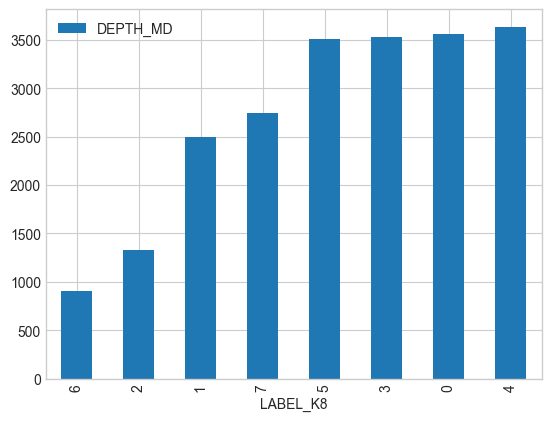

In [29]:
# 1st: look from depth
well_2527_copy[['DEPTH_MD','LABEL_K8']].groupby('LABEL_K8').median().\
                                        sort_values(by = 'DEPTH_MD', ascending = True).\
                                        plot(kind = 'bar');

In [33]:
well_2527_copy['DEPTH_MD'].describe()

count   2500.000
mean    2148.903
std     1094.089
min      204.594
25%     1235.800
50%     2146.850
75%     3101.638
max     4019.490
Name: DEPTH_MD, dtype: float64

> As we can see from the plot above, we can expect that the rock formations within clusters 2 and 6 are the nearest to the Earth's surface (<1500 m below the Earth's surface), while clusters 0, 3, 4, and 5 are the farthest from the Earth's surface (>= 3500 m below the Earth's surface). We can also conclude that clusters 1 and 7 are in between them.

We can also learn about these cluster characteristics based on the readings from logging tools. For example, we might want to investigate each cluster based on the presence of hydrogen atoms. This analysis is significant for detecting oil and gas resources.. We will get this information from the `NPHI` or neutron porosity column.

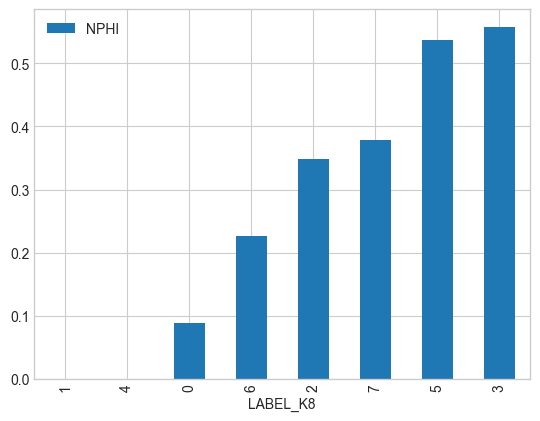

In [34]:
# 2st: look from neutron porosity
well_2527_copy[['NPHI','LABEL_K8']].groupby('LABEL_K8').median().\
                                        sort_values(by = 'NPHI', ascending = True).\
                                        plot(kind = 'bar');

> From the plot above, the clusters with the highest neutron porosity are 0, 1, 3, and 4, while the lowest are 2 and 6 (zero neutron porosity). [Reservoirs with pores filled with gas may exhibit lower neutron porosity compared to those filled with oil or water, due to gas having a lower concentration of hydrogen atoms than either oil or water](https://wiki.aapg.org/Density-neutron_log_porosity). Hence, we could expect that clusters with the highest neutron porosity contain more oil than those with lower porosity. However, the determination of the presence of oil and gas still needs to be guided by other logging tools readings, such as readings from density porosity part of logging tools.

Another way we can perform this cluster profiling is through visualization. In our case, where the determination of rock formation characteristics is highly reliant on the depth, we have prepared the `plot_depth_readings_cluster()` function  to plot the readings from logging tools corresponding to their depth. Additionally, this function also plots the colors indicating the corresponding clusters which we have generated with our K-means model. For comparison purposes, we can also plot the original labels of the data. This approach hopefully can save more time for geologists in determining the rock formations in the earth subsurface.

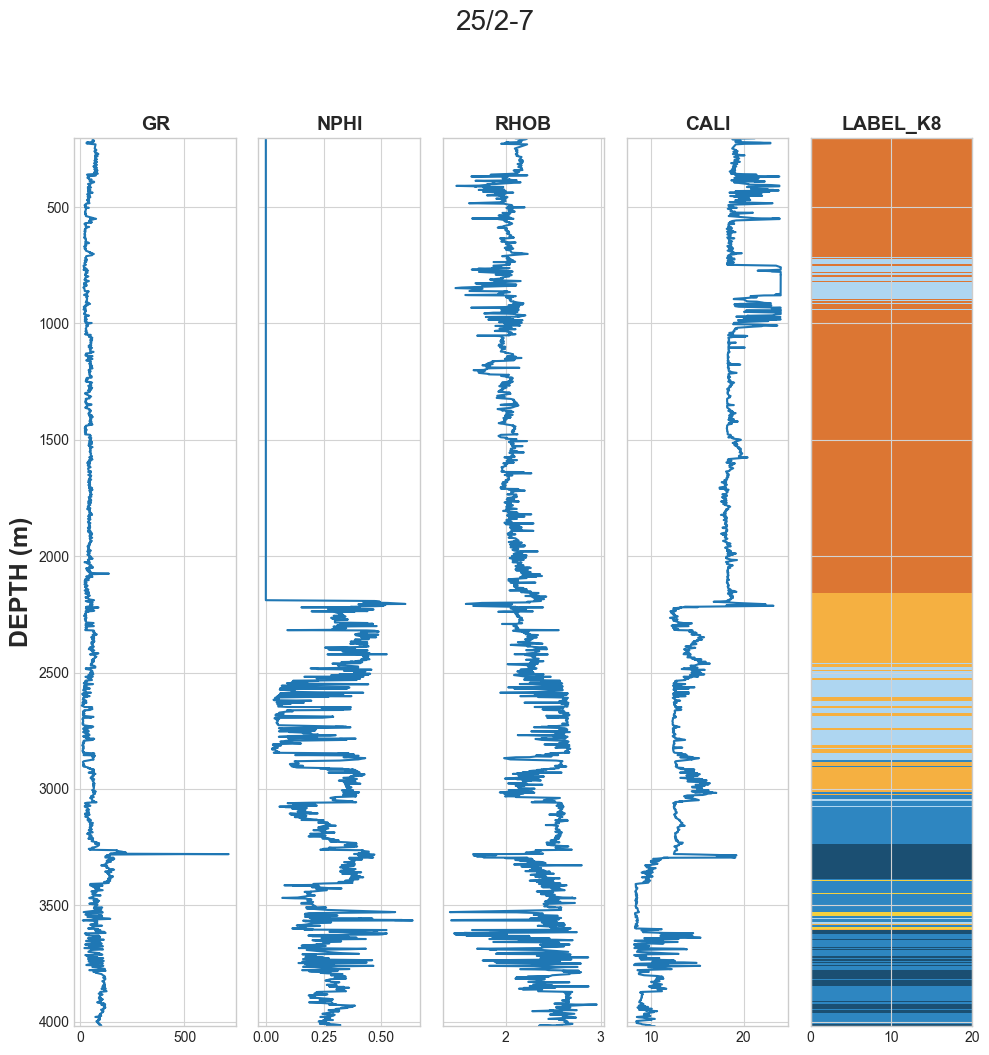

In [30]:
# setup the curves to plot
# GR: raw gamma --> from gamma ray tool
# NPHI : neutron porosity --> from neutron porosity part of logging tools
# RHOP: bulk density --> from density part of logging tools
# CALI: caliper --> from caliper part of logging tools


curves_to_plot = ['GR', 'NPHI','RHOB','CALI','LABEL_K8'] # add 'LITHOLOGY_CLASS' to plot the actual lithology class
logarithmic_curves = ['RDEP']
facies_curve=['LABEL_K8'] # add 'LITHOLOGY_CLASS' to plot the actual lithology class

# Create plot by passing in the relevant well index number
cmap_facies = plot_depth_readings_cluster("25/2-7", 
            well_2527_copy, 
            curves_to_plot, 
            well_2527_copy['DEPTH_MD'], 
            logarithmic_curves, facies_curve)

In [36]:
well_2527_copy.head(479)['LABEL_K8'].unique()

array([1, 4])

The first thing to note is that when you include `LITHOLOGY_CLASS` to be plotted, the same color between the last two plots (the actual and the prediction from clustering method) doesn't signify the same group. 

As we can see from the plot above, our labels from K-means clustering shift as the readings from logging tools fluctuate. The depth of the same color is expected to signify the same rock formation. For example, let's identify the rock formations with the colors of light blue and dark orange within the depth of 0-2000. As we can see from the plot above, we could expect there are two rock formations in this range. Let's find out to which cluster this rock formations belong.

In [37]:
well_2527_copy[well_2527_copy['DEPTH_MD'] < 2000]['LABEL_K8'].unique()

array([1, 4])

Clusters 2 and 6, based on our previous findings, are the rock formations that are nearest to the Earth's surface. These formations also have zero neutron porosity. Hence, the depths of these clusters are highly likely to contain less oil substance compared to other clusters.

Furthermore, observe the `NPHI` plot where it suddenly reaches a peak starting at a certain depth, around 2200. As you can see from the last plot, this change in `NPHI` value also changes the cluster of rock formation, denoted by the color bright orange.

In [38]:
well_2527_copy[(well_2527_copy['DEPTH_MD'] > 2200) & (well_2527_copy['DEPTH_MD'] < 2215)]['LABEL_K8'].unique()

array([7])

Cluster 1, based on our previous findings, is the rock formation that is nearest to the Earth's surface after clusters 2 and 6. This cluster exhibits the third largest value for its neutron porosity. Based on these findings, we could expect a higher concentration of hydrogen atoms in this rock formation with cluster 1. However, to determine if the hydrogen atoms indicate oil, experts often conduct cross-analysis between neutron porosity readings and other readings, such as bulk density readings.

This method can help geologists automatically map rock formations within the Earth's subsurface. Additionally, we can compare the real mappings to those from K-means clustering. Despite slightly different results, we could still leverage unsupervised learning to automate this mapping process. In the next section, we will explore another clustering method: K-medoids.

## K-Medoids Clustering

**The Partitioning around Medoids (PAM)** algorithm, or **K-medoids**, is a non-hierarchical clustering method that is closely related to the K-means method. The K-medoids method groups a set of $n$ objects into $k$ clusters. So, what is the difference from the K-means method? The difference lies in how the clustering is done.

In the K-means method, the determination of an object into a particular cluster is based on the calculation of the average Euclidean distance. Meanwhile, the K-medoids method begins with the determination of medoids (an object that is centered in a cluster). From the image below, we can see the difference between the K-means and K-medoids methods in determining which object is more suitable for a particular cluster.

![](assets/k-means-and-k-medoids.png)

The determination of medoids is not done only once but repeatedly until the medoids can no longer move. Why not just once? Because the placement of medoids is not necessarily in the most optimal position. To find the most optimal position, the initial medoids' position will be recalculated for the total deviation using the formula below.

$$
S = b - a  
$$

where:   

* **a** is the sum of the closest distances from objects to the initial medoid.
* **b** is the sum of the closest distances from objects to the new medoid.

If \(S < 0\), then swap objects with data to form a new set of $k$ medoids.

This step will continue to be repeated until $S > 0$, which means there is no more movement from the medoid chosen as the center point. From the most optimum medoids' point, we will look for objects that resemble the characteristics of the medoids. For a better understanding of how the PAM method works, refer to the visualization below.

![](assets/K-Medoids_Clustering.gif)

> Unlike K-means, which we primarily use for numerical data, K-medoids works well if we have categorical data as a characteristic when conducting clustering. Additionally, [K-medoids can be more robust to noise and outliers than K-means as it will choose one of the cluster members as the medoid while K-means will move the center of the cluster towards the outlier which might in turn move other points away from the cluster centre](https://scikit-learn-extra.readthedocs.io/en/stable/modules/cluster.html).

To gain a better understanding of K-medoids, let's apply the K-medoids method to our repeatedly used `well_num_scaled` dataframe!

### Gower Distance

In contrast to the implementation of K-means, we feed the Gower matrix into our K-medoids model object. The Gower matrix is used to calculate the distance matrix for a dataset using Gower's method. Gower distance measures the distance between two samples. To achieve this, we can use the `gower_matrix()` function from the `gower` library.

In [39]:
well2527_gower = go.gower_matrix(well_num_scaled)

In [40]:
well2527_gower

array([[0.        , 0.04212509, 0.04320497, ..., 0.40245235, 0.40785533,
        0.398432  ],
       [0.04212509, 0.        , 0.00348635, ..., 0.3966061 , 0.40199286,
        0.3925692 ],
       [0.04320497, 0.00348635, 0.        , ..., 0.3959582 , 0.40134495,
        0.39192128],
       ...,
       [0.40245235, 0.3966061 , 0.3959582 , ..., 0.        , 0.01010373,
        0.01506065],
       [0.40785533, 0.40199286, 0.40134495, ..., 0.01010373, 0.        ,
        0.01780209],
       [0.398432  , 0.3925692 , 0.39192128, ..., 0.01506065, 0.01780209,
        0.        ]], dtype=float32)

### Optimal Number of Cluster

When working with K-medoids, we also determine the number of clusters we wish to generate. The approach is quite similar to that of K-means, utilizing either a business approach or a statistical/mathematical approach. In the statistical/mathematical approach, we can use the same elbow method to determine $k$, which minimizes the sum of distances between each point and the medoid of its cluster.

We have prepared the `plot_elbow_kmedoids()` function in the helper script. To choose which $k$ to use, we can observe where the decrease in the plot slows down (in the elbow part).

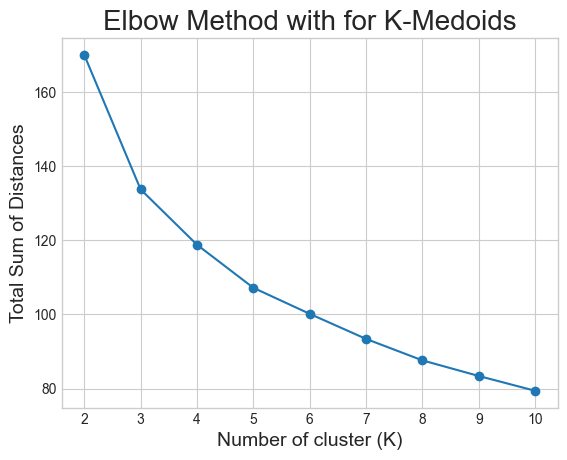

In [41]:
plot_elbow_kmedoids(well2527_gower)

From the image above, the elbow or the $k$ value where the decrease in the sum of distances is not too drastic is around $k = 8$ or $k = 9$.

### K-Medoids Implementation

The implementation of K-medoids is quite similar to that of K-means. We define the model object and fit the data to the model object. The object we will use is `KMedoids()`, which comes from the `sklearn_extra.cluster` module. There are four parameters of this object we need to specify:

- `n_clusters`: the number of clusters we want to create.
- `metric`: the distance metric to use. Since we pass the Gower matrix to the model, set this to `"precomputed"`.
- `method`: which algorithm to use. Set to `"pam"`.
- `random_state`: to lock in randomness.

Like any other modeling process, the `KMedoids()` object will be followed by the `.fit()` function to learn the characteristics of the data and generate clusters.

In [42]:
# try k = 8
kmed_lith8 = KMedoids(n_clusters = 8, 
                    metric = "precomputed",
                    method = 'pam',
                    random_state = 123).fit(well2527_gower)
kmed_lith8

,n_clusters,8
,metric,'precomputed'
,method,'pam'
,init,'heuristic'
,max_iter,300
,random_state,123


To display the clustering result label for each observation, you can use the following method.

In [43]:
# label from k = 8
label8_kmed = kmed_lith8.labels_

# 10 first labels
label8_kmed[:10]

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6], dtype=int64)

### Cluster Profiling

Like K-means, the last part of the K-medoids clustering stage involves profiling based on the information in each formed cluster. This stage aims to identify the characteristics of each cluster. The process includes assigning the labels formed back to our original data.

In [44]:
# assign label from K-medoids with 8 clusters
well_2527_copy['LABEL_KMED8'] = kmed_lith8.labels_

In [45]:
well_2527_copy.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LABEL_K8,LABEL_K12,LABEL_KMED8
0,25/2-7,204.594,479890.531,6641111.500,-179.591,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,1,1,6
1,25/2-7,206.722,479890.531,6641111.500,-181.719,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,1,1,6
2,25/2-7,208.850,479890.531,6641111.500,-183.847,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,1,1,6
3,25/2-7,212.802,479890.531,6641111.500,-187.799,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Sandstone/Shale,1,1,6
4,25/2-7,212.954,479890.531,6641111.500,-187.951,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,Sandstone/Shale,1,1,6


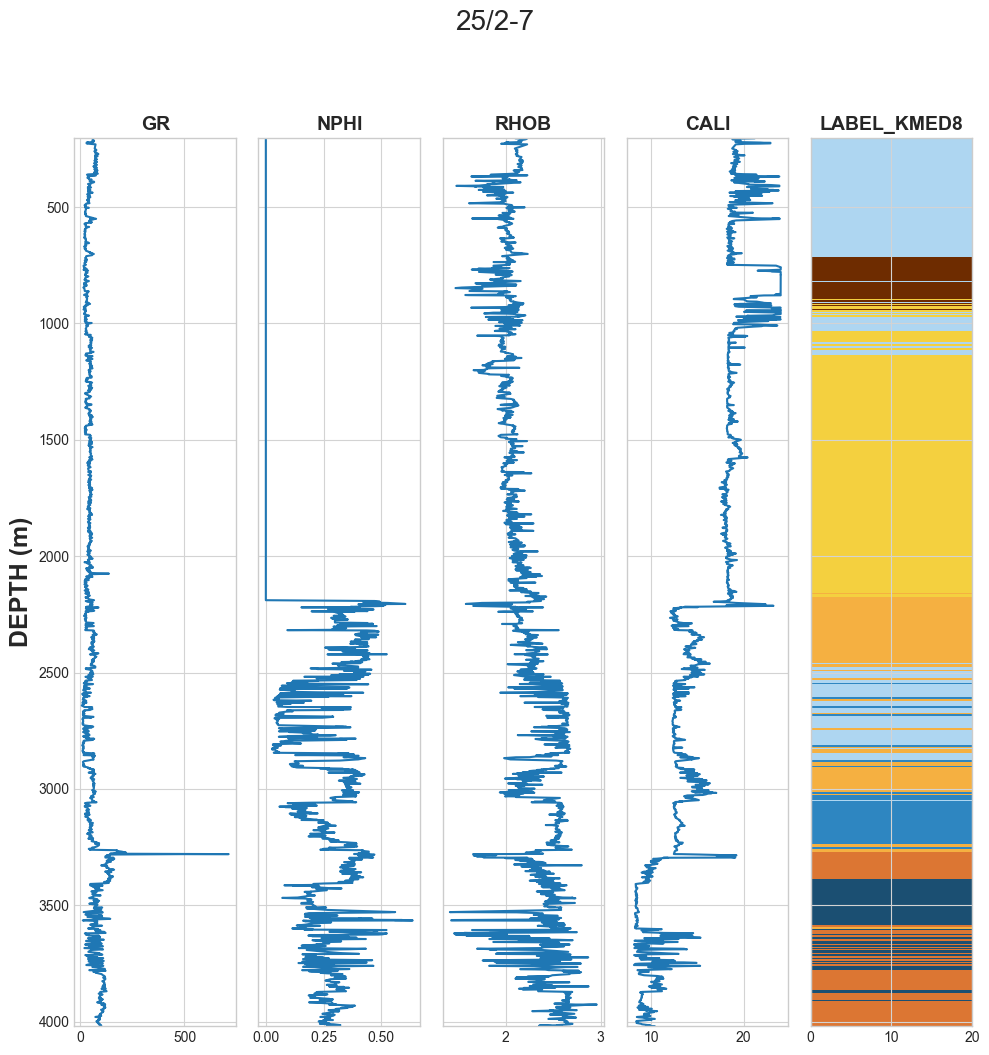

In [46]:
# comparison among the real labels, the labels from K-means, and the labels from K-medoids

# setup the curves to plot
# GR: raw gamma --> from gamma ray tool
# NPHI : neutron porosity --> from neutron porosity part of logging tools
# RHOP: bulk density --> from density part of logging tools
# CALI: caliper --> from caliper part of logging tools


curves_to_plot = ['GR', 'NPHI','RHOB','CALI','LABEL_KMED8'] # add 'LITHOLOGY_CLASS' to plot the actual lithology class
logarithmic_curves = ['RDEP']
facies_curve=['LABEL_KMED8'] # add 'LITHOLOGY_CLASS' to plot the actual lithology class

# Create plot by passing in the relevant well index number
cmap_facies = plot_depth_readings_cluster("25/2-7", 
            well_2527_copy, 
            curves_to_plot, 
            well_2527_copy['DEPTH_MD'], 
            logarithmic_curves, facies_curve)

Based on the clustering profiling approaches we have learned in the K-means section, try to interpret the cluster generated from K-medoids. You are welcome to compare the labels generated from K-means and K-medoids using various techniques you learned from previous courses!

# Summary

After learning about unsupervised machine learning, we now know that for unlabeled data, we can analyze it using clustering methods. Clustering helps us recognize the characteristics of the observations by grouping individuals based on the similarity of their characteristics.


The studied clustering methods, K-means and K-medoids, are algorithms used to group similar data. K-means searches for cluster centers by minimizing the distance between data points and cluster centers, while K-medoids uses medoids as a representation of clusters, making it more resistant to outliers. Both algorithms require initialization and an iterative process to reach the optimal solution. K-means has the advantages of computational efficiency and simplicity but is sensitive to initialization and less suitable for data with complex cluster structures. In contrast, K-medoids is more tolerant of outliers but requires more computational resources. The choice between the two depends on the nature of the data and tolerance for outliers, and both have important roles in data analysis.

Disclaimer, clustering methods are not the absolute answer when we face unlabeled data or when we are looking for a common characteristic in our data observations. If we don't get a satisfactory answer from the clustering method, at least we can utilize the clustering method as an initial intuition in dealing with the problem.

With this understanding, we can tackle unlabeled data more effectively and gain valuable insights into the patterns hidden in the data.